# Learning Local Deviations via Reinforcement Learning

In [Implementing a Drive-Based Controller with Memory](./drive-based-controller.ipynb), we developed a simple, unlearned controller that sets goals based on drive classification over remembered sensory inputs. We also added a local map to this controller that allowed it to deviate from its goals slightly to avoid threats and approach opportunities.

This agent has a fundamental flaw, though, in that it cannot "see" the rewards it is getting or not getting. The classifier is trained to classify the tree embeddings, but the "smell" sensor does not naturally localize since it is a proximity sensor. Without a way to move from proximity to exact location, the agent can only find food by getting lucky.

We could fix this by introducing a directional "vision" sensor with a more distinct range. However, it would be interesting to know what we can do with the imprecise smell sensor, which does contain directional information that could be extracted when combined with the knowledge of where rewards were obtained.

In this notebook, we will use reinforcement learning to control the local deviations from target so that the agent can exploit better.

## Capturing Rewards

In order to do any reinforcement learning, we have to first alter our agent to record the results of when it has eaten fruit and pass this to the model. This requires updating `AgentModel.get_action` to take a `reward` parameter.

In [20]:
import torch

class Agent:
    # ...
    def step(self, world: 'TreeWorld'):
        distance, embedding, tree = self.sensor.sense(world, self.location, self.heading)

        reward = 0.0
        if tree is not None and distance < self.eat_distance:
            # print(f"Eating fruit from tree {tree.name} with fruit amount {num_fruit}")
            self.fruit_eaten += 1
            reward = 1.0
            if tree.is_poisonous:
                self.poisonous_fruit_eaten += 1
                reward = -1.0

            # NOTE: this requires the agent to face the tree when eating fruit
            self.eat_fruit(1, tree.is_poisonous)
            tree.harvest_fruit()
        
        position_delta, self.heading = self.model.get_action(
            distance, 
            embedding, 
            self.heading, 
            self.health / self.max_health,
            agent_location=self.location, 
            obj_location=tree.location if tree is not None else None, 
            reward=reward
        )

        if position_delta is None or torch.norm(position_delta) < 1e-8:
            self.rest()
        else:
            self.move(position_delta)
    # ...

In [21]:
class AgentModel:
    def get_action(self, distance: float, embedding: torch.Tensor, heading: torch.Tensor, health: float,
                   agent_location: torch.Tensor=None, obj_location: torch.Tensor=None, reward: float=0.0):
        # ...
        pass

## Implementing a REINFORCE-style Policy Gradient

Policy gradient methods use a neural network policy to decide on actions. That is, they sample a distribution
$$
a_t \sim \pi_\theta(a \mid s_{\leq t}, a_{<t}).
$$ 
In our case, we already have a heading $h_t$, and we are looking for a deviation $d_t \in \mathbb{R}$ so that we can output
$$
a_t = h_t + d_t o_t
$$
where $o_t$ is the left-pointing orthonormal vector from the heading $h_t$. We also do not need to condition the decision on past actions or past states. Thus we want our policy to sample
$$
d_t \sim \pi_\theta(d \mid s_t, d_{t-1})
$$
where $s_t$ is just the local map developed towards the end of [Implementing a Drive-Based Controller with Memory](./drive-based-controller.ipynb) and $d_{t-1}$ provides a view into the last decision for consistency.

As is typical, the policy is learned by optimizing the discounted sum of rewards with discount $\gamma \in (0, 1]$, using the log-trick
$$
\mathcal{L} = \mathbb{E}_{\pi} \left[\sum_t \gamma R_t\right], \quad\quad
\nabla_\theta \mathcal{L} = \mathbb{E}_{\pi} \left[A_t \nabla_\theta\left\{\vphantom{x^{x^{x^{x^x}}}}\sum_t \log \pi_\theta(d_t \mid s_t, d_{t-1})\right\}\right]
$$
where $A_t$ is the _advantage_ against a baseline $B_t$ that is independent of $\theta$ (and hence $\nabla_\theta B_t = 0$),
$$
A_t = \left(\sum_t \gamma R_t\right) - B_t
$$
Methods such as PPO and GRPO craft this baseline carefully, but in our case, we will be starting with online policy learning against a baseline from the simple drive-based controller without RL.

Every 100 steps we will update our policy using $\nabla_\theta \mathcal{L}$ based on rewards achieved from the past 100 steps. We will alternate between using the policy to guide the agent (on-policy) and using the non-learned drive-based controller (off-policy) every other simulation. The baseline will be updated only when the non-learned policy is used. We will only train when the total rewards is non-zero.

For reference, we will be using `build_forward_local_map` with `return_raw_drives=True` to create our input $s_t$

In [22]:
import math
from tree_world.states import DriveManager, Location
from tree_world.models.memory import SpatialMemory


def build_forward_local_map(
    memory: SpatialMemory,
    location: Location,
    heading: torch.Tensor,
    drive_manager: DriveManager,
    num_grid_points: int=10,
    grid_size: float=10.0,
    match_threshold: float=25.0,
    return_raw_drives: bool=False,
):
    axis_points = torch.arange(num_grid_points, dtype=heading.dtype, device=heading.device)
    axis_grid = torch.cartesian_prod(axis_points, axis_points)

    # we want to get the vector to the diagonal of the grid, which is y=x
    rotation_matrix = math.sqrt(0.5) * torch.tensor([
        [1, 1],
        [-1, 1],
    ], dtype=heading.dtype, device=heading.device)

    grid_points_relative = (axis_grid @ rotation_matrix.T) * grid_size

    heading_normalized = heading / torch.norm(heading)
    heading_orthogonal = torch.tensor([-heading_normalized[1].item(), heading_normalized[0].item()], 
                                      dtype=heading.dtype, device=heading.device)[None, :]

    grid_points_absolute = location.location[None, None, :] + (
        grid_points_relative[..., 0, None] * heading_normalized + grid_points_relative[..., 1, None] * heading_orthogonal
    )[None, ...]

    grid_locations_sd = torch.ones_like(grid_points_absolute) * grid_size / 2

    memory_values = memory.read(grid_points_absolute, grid_locations_sd, match_threshold=match_threshold).squeeze(0)
    grid_valence = drive_manager.assess_valence(memory_values, return_raw_drives=return_raw_drives)

    deviations = grid_points_relative[..., 1] 

    return grid_points_absolute, grid_valence, deviations, heading_orthogonal

We will use the `grid_valence`, which is a tensor of shape (num_grid_points, num_grid_points, 3), as our network input $s_t$, and `heading_orthogonal` as the orthogonal unit vector $o_t$.

Here is a simple MLP for the policy network:

In [23]:
from typing import Optional

class LocalMapPolicy(torch.nn.Module):
    def __init__(self, drive_field_dim: int, hidden_dim: int=128, scale: float=25.0):
        super().__init__()
        self.scale = scale

        self.fc1 = torch.nn.Linear(drive_field_dim + 1, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, 2)

    def forward(self, x: torch.Tensor, last_coefficient: torch.Tensor, output: Optional[torch.Tensor]=None) -> torch.Tensor:
        x = torch.relu(self.fc1(torch.cat([x, last_coefficient], dim=1)))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        mean_output = x[:, 0] * self.scale
        std_output = torch.nn.functional.softplus(x[:, 1])

        if output is None:
            output = mean_output + std_output * torch.randn_like(mean_output)

        log_prob = -torch.log(std_output) - 0.5 * ((output - mean_output) / std_output) ** 2 - 0.5 * math.log(2 * math.pi)
        return output, log_prob.mean()

The output is scaled by a factor that should be equal to $C =$ `grid_size` $\times$ `num_grid_points` $ / 4$ so that the neural network output can be scaled to the range $[-C, C]$ from the raw weight output of $[-1, 1]$.

We'll also put a small penalty on switching the sign of the coefficient, to encourage "differentiable" trajectories.

Finally, we can extend `tree_world.drive_agents.DriveBasedAgentWithMemory` to implement the policy-backed controller.

In [24]:
from tree_world.drive_agents import DriveBasedAgentWithMemory, apply_deviation
from tree_world.simulation import TreeWorld
from typing import Optional

class DriveBasedAgentWithLocalPolicy(DriveBasedAgentWithMemory):
    deviation_strength: float = 5.0

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.grid_size = 5.0
        self.num_grid_points = 5

        drive_field_dim = self.num_grid_points * self.num_grid_points * 3
        self.policy = LocalMapPolicy(drive_field_dim, scale=self.grid_size * self.num_grid_points / 4)
        self.optimizer = torch.optim.AdamW(self.policy.parameters(), lr=1e-3)
        self.total_rewards = 0.0
        self.total_rewards_baseline = 0.0
        self.total_rewards_baseline_decay = 0.9
        self.total_log_probs = 0.0

        self.use_policy = True

        self.last_coefficient = 0.0

    def reset(self):
        super().reset()
        self.total_rewards = 0.0
        self.last_coefficient = 0.0

        self.use_policy = not self.use_policy
        # print the execution stack to see who is calling reset
        if self.use_policy:
            print(f"Using policy model")
        else:
            print(f"Using baseline model")
    
    def update_rewards(self, reward: float):
        self.total_rewards += reward

    def heading_from_policy(self, heading: torch.Tensor, agent_location: Location, output: Optional[torch.Tensor]=None):
        _, drive_field, _, heading_orthogonal = build_forward_local_map(
            self.memory, agent_location, heading, self.drive_manager, 
            num_grid_points=self.num_grid_points, grid_size=self.grid_size, 
            match_threshold=25.0, return_raw_drives=True
        )

        drive_field = drive_field.view(1, -1)
        last_coefficient = torch.tensor([[self.last_coefficient]], dtype=drive_field.dtype, device=drive_field.device)

        coefficient, log_prob =self.policy(drive_field.detach(), last_coefficient, output)
        self.total_log_probs = self.total_log_probs + log_prob

        raw_heading = heading + coefficient.squeeze(0) * heading_orthogonal.squeeze(0)
        heading_norm = torch.norm(heading)
        return (heading_norm * raw_heading / torch.norm(raw_heading)).detach(), coefficient.squeeze(0)
    
    def heading_from_deviation(self, heading: torch.Tensor, agent_location: Location):
        return apply_deviation(
            agent_location, heading, self.memory, self.drive_manager, 
            deviation_strength=self.deviation_strength,
            num_grid_points=5, grid_size=5.0, match_threshold=25.0,
            return_coefficient=True
        ).detach().squeeze()
    
    def adjust_heading(self, heading: torch.Tensor, agent_location: Location):
        if self.use_policy:
            heading, coefficient = self.heading_from_policy(heading, agent_location)
            self.last_coefficient = coefficient.item()
            return heading
        else:
            output = self.heading_from_deviation(heading, agent_location)
            return self.heading_from_policy(heading, agent_location, output)[0]

    def train(self):
        super().train()

        if self.total_rewards == 0.0:
            return

        self.optimizer.zero_grad()

        advantage = self.total_rewards - self.total_rewards_baseline
        loss = -advantage * self.total_log_probs

        loss.backward()

        self.optimizer.step()

        if not self.use_policy:
            d = self.total_rewards_baseline_decay
            self.total_rewards_baseline = self.total_rewards_baseline * d + self.total_rewards * (1.0 - d)

        self.total_log_probs = 0.0
        self.total_rewards = 0.0

## Testing the RL Policy

Our simulation will call `train` every 100 steps on any agent model that has a `train` method, meaning that our model will be trained online every 100 steps. We'll want to run a few runs to track the policy.

In [25]:
from tree_world.simulation import TreeWorldConfig, TreeWorld, SimpleSensor

R = 50
D = 1024
S = 2 * R + 1
real_magnitude = 500.0

config = TreeWorldConfig()
config.embed_dim = D
config.max_memory_size = S**2

config.model_type = "DriveBasedAgentWithLocalPolicy"

sensor = SimpleSensor.from_config(config)
world = TreeWorld.random_from_config(config)

Drive Embedding Classifier Loss (with fruit amount): 0.3053666055202484 MSE: 8.096726560324896e-06 Accuracy: 100.00%


In [26]:
def run_simulation(world: TreeWorld, steps: int=1000, record: bool=False):
    world.randomize()

    print(f"Running tree world for {steps} steps...")
    world.run(steps, record=record)
    print()
    print("Tree world run complete.")

    print(f"Agent health: {world.agent.health}")
    print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
    print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
    print(f"Agent total movement: {world.agent.total_movement}")
    print(f"Agent final location: {torch.norm(world.agent.location).item()}")

for i in range(50):
    run_simulation(world, steps = (i + 1) * 1000)

Using baseline model
Running tree world for 1000 steps...

Tree world run complete.
Agent health: 799.98779296875
Agent fruit eaten: 32
Agent poisonous fruit eaten: 16
Agent total movement: 1000.0
Agent final location: 511.715087890625
Using policy model
Running tree world for 2000 steps...

Tree world run complete.
Agent health: 655.3789672851562
Agent fruit eaten: 19
Agent poisonous fruit eaten: 0
Agent total movement: 2000.0
Agent final location: 323.0830993652344
Using baseline model
Running tree world for 3000 steps...

Tree world run complete.
Agent health: 839.990234375
Agent fruit eaten: 55
Agent poisonous fruit eaten: 0
Agent total movement: 3000.0
Agent final location: 365.2728576660156
Using policy model
Running tree world for 4000 steps...

Tree world run complete.
Agent health: 299.951171875
Agent fruit eaten: 34
Agent poisonous fruit eaten: 15
Agent total movement: 4000.0
Agent final location: 128.1287078857422
Using baseline model
Running tree world for 5000 steps...

Tr

In [31]:
world.agent.model.use_policy = False # <-- this will toggle back to true after the world is reset
run_simulation(world, steps=10000,record=True)

Using policy model
Running tree world for 10000 steps...

Tree world run complete.
Agent health: 898.1937866210938
Agent fruit eaten: 160
Agent poisonous fruit eaten: 0
Agent total movement: 10000.0
Agent final location: 352.5928649902344


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


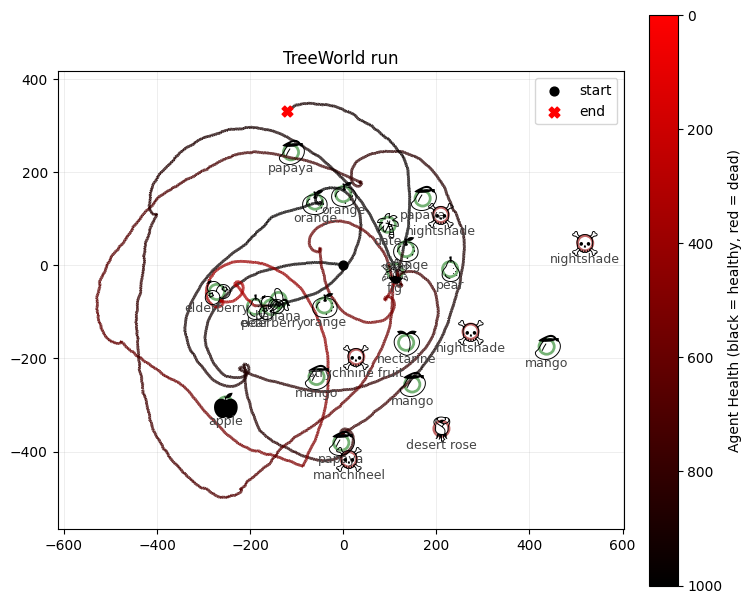

In [32]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

# Conclusion

Our RL policy has learned to optimize a bit over our baseline policy; in particular, it can exploit rewards a bit better. In a few cases, the RL policy survives indefinitely (10,000+ steps). However, it has a few deficiences:
- Our RL policy needs a better baseline, which will take a little work to craft (GAE or PPO)
- Our sensors are still too impoverished and could give the agent better information; for instance, neither controller can see poison fruit very well when it is close to edible fruit.
- Our RL policy can't really plan; it is reactive and runs step by step

Given these issues, rather than working more on the RL policy at this time, it would be best to work on the following:
1. Improve our ability to locate and identify reward states, for instance by learning the drive classifier from sensors + rewards
2. Work on planning over the memory, perhaps by diffusing a high-reward trajectory to the goal from the memory
3. Add a local sensor to give better information about the local environment to the controller

With that said, I want to emphasize the following claim:

*Using a spatial map, a set of drives, and a goal-driven control framework, the task of building an RL controller has been made far simpler than training a controller just on the sensory inputs*

This claim remains to be proven; I may add a general policy gradient controller above to compare the difficulty of learning.